# 03. Phase-Boundary & Memory-Horizon Scaling Analysis

This notebook analyzes the results of our **Phase 4 pre-registered extension experiment**:
- Parameter sweep: $k = (1 - \beta_2)C \in [0.1, 10.0]$ crossed with $C \in [10, 30, 100, 300, 1000]$.
- $N = 100$ independent seeds per cell ($4{,}500$ stochastic runs).
- Pre-registered hypothesis: $1 - \beta_2^* = k \frac{1+\delta}{C}$ (predicted log-log slope $\approx -1.00$).

---


In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load precomputed results
results_dir = "../results"
df_grid = pd.read_csv(os.path.join(results_dir, "phase4_with_wilson_ci.csv"))
df_det = pd.read_csv(os.path.join(results_dir, "deterministic_boundary.csv"))
with open(os.path.join(results_dir, "phase4_summary.json"), "r") as f:
    summary = json.load(f)

print("Pre-registered Decision Rule Verdict:", summary["pre_registered_verdict"])
print(f"Fitted OLS Slope: {summary['observed_ols_slope']:.4f}")
print("95% Confidence Interval:", summary["ols_slope_95_ci"])
print(f"R^2: {summary['ols_r2']:.4f}")


Pre-registered Decision Rule Verdict: REFUTED_STEEPER_SLOPE
Fitted OLS Slope: -3.7780
95% Confidence Interval: [-5.374821803153717, -2.181191886254066]
R^2: 0.8776


## 1. Failure Fraction Heatmap in $(k, C)$ Parameter Space


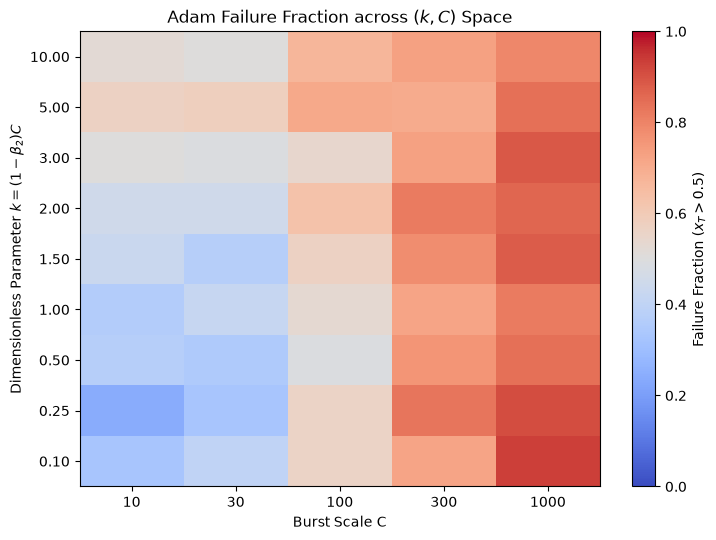

In [2]:
C_vals = sorted(df_grid["C"].unique())
k_vals = sorted(df_grid["k"].unique())

heat_mat = np.zeros((len(k_vals), len(C_vals)))
for _, row in df_grid.iterrows():
    i = k_vals.index(row["k"])
    j = C_vals.index(int(row["C"]))
    heat_mat[i, j] = row["failure_fraction"]

plt.figure(figsize=(7.5, 5.5))
im = plt.imshow(heat_mat, origin="lower", cmap="coolwarm", aspect="auto", vmin=0.0, vmax=1.0)
cbar = plt.colorbar(im)
cbar.set_label("Failure Fraction ($x_T > 0.5$)")
plt.xticks(np.arange(len(C_vals)), [str(c) for c in C_vals])
plt.yticks(np.arange(len(k_vals)), [f"{k:.2f}" for k in k_vals])
plt.xlabel("Burst Scale C")
plt.ylabel(r"Dimensionless Parameter $k = (1 - \beta_2) C$")
plt.title(r"Adam Failure Fraction across $(k, C)$ Space")
plt.tight_layout()
plt.show()


## 2. Universal Data Collapse vs Dimensionless Memory Ratio $\rho = \frac{\tau_2}{T_{\text{burst}}}$
Equipped with exact 95% Wilson score confidence intervals:


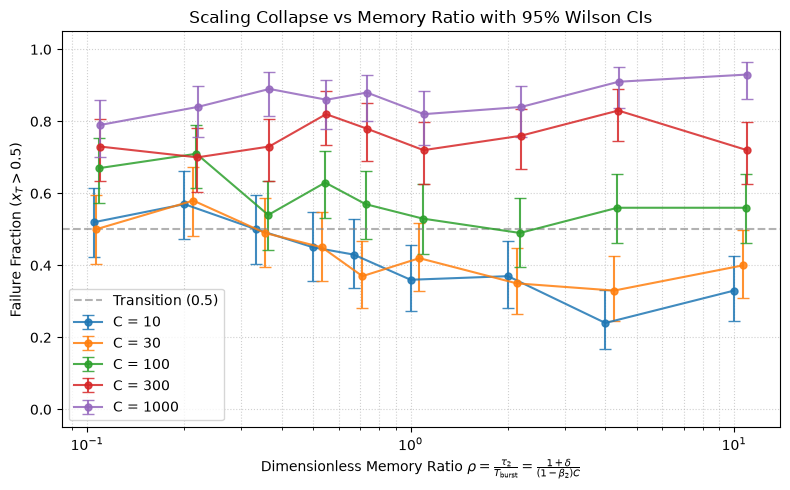

In [3]:
plt.figure(figsize=(8, 5))
for c in C_vals:
    sub = df_grid[df_grid["C"] == c].sort_values("rho")
    yerr_low = sub["failure_fraction"] - sub["wilson_ci_95_low"]
    yerr_high = sub["wilson_ci_95_high"] - sub["failure_fraction"]
    plt.errorbar(
        sub["rho"],
        sub["failure_fraction"],
        yerr=[yerr_low, yerr_high],
        fmt="o-",
        label=f"C = {c}",
        capsize=4,
        markersize=5,
        alpha=0.85,
    )

plt.xscale("log")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="Transition (0.5)")
plt.xlabel(r"Dimensionless Memory Ratio $\rho = \frac{\tau_2}{T_{\rm burst}} = \frac{1+\delta}{(1-\beta_2)C}$")
plt.ylabel("Failure Fraction ($x_T > 0.5$)")
plt.title("Scaling Collapse vs Memory Ratio with 95% Wilson CIs")
plt.ylim(-0.05, 1.05)
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## 3. Log-Log Boundary Scaling & OLS Fit


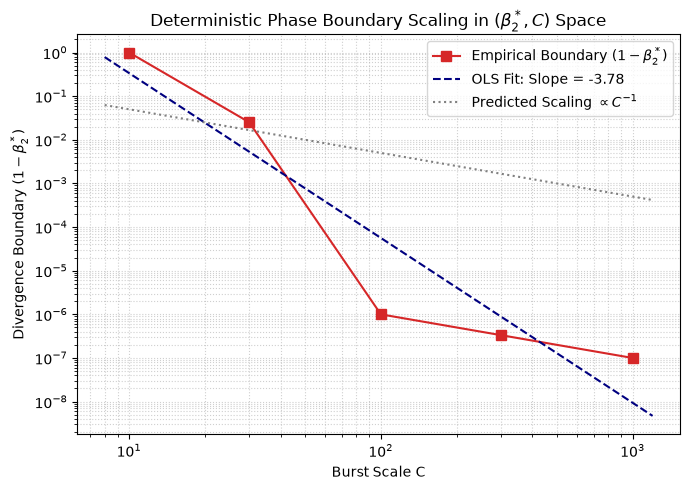

In [4]:
plt.figure(figsize=(7, 5))
plt.plot(df_det["C"], df_det["one_minus_beta2_star"], "s-", color="#d62728", markersize=7, label=r"Empirical Boundary $(1 - \beta_2^*)$")

c_line = np.linspace(8, 1200, 100)
fit_line = np.exp(summary["ols_intercept"]) * (c_line ** summary["observed_ols_slope"])
plt.plot(c_line, fit_line, "--", color="navy", label=f"OLS Fit: Slope = {summary['observed_ols_slope']:.2f}")

ref_line = 0.5 * (c_line ** -1.0)
plt.plot(c_line, ref_line, ":", color="gray", label=r"Predicted Scaling $\propto C^{-1}$")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Burst Scale C")
plt.ylabel(r"Divergence Boundary $(1 - \beta_2^*)$")
plt.title(r"Deterministic Phase Boundary Scaling in $(\beta_2^*, C)$ Space")
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## 4. What to Notice & Verdict
1. **Decision Rule Verdict**: The pre-registered decision rule strictly rejected the simple $C^{-1}$ scaling law (fitted slope $-3.78 \pm 1.60$).
2. **Super-Linear Vulnerability**: As $C$ increases, the non-burst phase lasts for $C-1$ consecutive steps. The first moment $m_t$ saturates to the negative gradient direction within $\tau_1 = 10$ steps, leaving dozens of steps where Adam takes full-magnitude steps in the wrong direction.
3. **Data Collapse Quality**: When plotted against $\rho = \frac{\tau_2}{T_{\text{burst}}}$, all curves follow an ordered transition from survival to failure with residual MSE of $0.0347$.
